# Predicting Heart Disease

The [World Health Organization (WHO)](https://www.who.int/health-topics/cardiovascular-diseases) estimates that 17.9 million people die from cardiovascular diseases (CVDs) every year.

There are multiple risk factors that could contribute to CVD in an individual, such as unhealthy diet, lack of physical activity, or mental illness. Identifying these risk factors early on could help prevent many premature deaths.

Our goal to use the [dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) to accurately predict the likelihood of a new patient having heart disease in the future.

## Exploratory Data analysis

In [1]:
# import necessary library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Read the dataset
heart_disease = pd.read_csv('../../dataset/heart_disease_prediction.csv')
heart_disease.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
# Check the number of features and observations
heart_disease.shape

(918, 12)

There are 12 features and 918 observations in this dataset.

## EDA: Descriptive Statistics`

In [3]:
# Display the descriptive statistics
heart_disease.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [4]:
heart_disease.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

There are `7` numerical columns and `5` categorical column. But FastingBS adn Heart_Disease are also numercial column as they have 0, and 1 as value.

In [5]:
heart_disease.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


THe average age of patient in this dataset is `53.5`. The minimum value in RestingBp, cholestrol is zero which might indicate error in data-entry or recording.
As per the dataset description, Cholesterol contains the serum cholesterol values. And per the [American Heart Association](https://www.heart.org/en/health-topics/cholesterol/about-cholesterol/what-your-cholesterol-levels-mean), serum cholesterol:
is a composite of different measurements. Your total blood cholesterol is calculated by adding your HDL and LDL cholesterol levels, plus 20% of your triglyceride level.

The above information is enough to let us know that a 0 value for serum cholesterol is unlikely.

In [6]:
# check the missing value
heart_disease.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
heart_disease.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

No, missing value is present in the dataset. 

## EDA: Visualizations

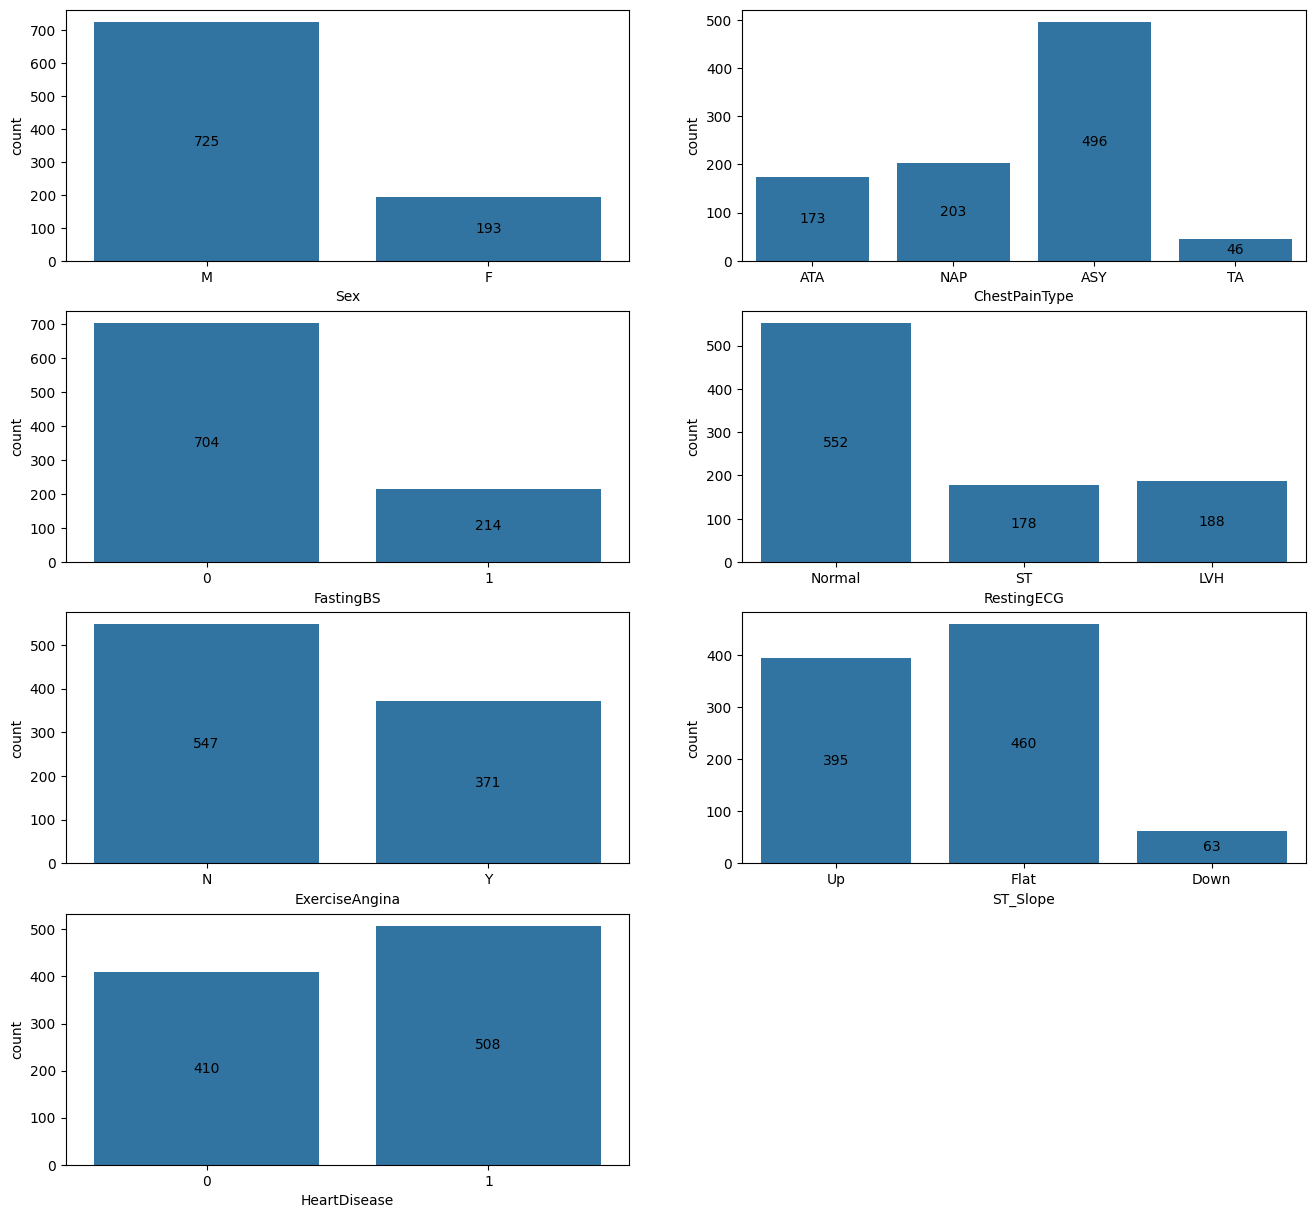

In [8]:
categorical_column = ['Sex', 'ChestPainType', 'FastingBS','RestingECG', 'ExerciseAngina', 'ST_Slope',
       'HeartDisease']

fig = plt.figure(figsize = (16, 15))
for idx, column in enumerate(categorical_column):
    ax = plt.subplot(4, 2, idx+1)
    sns.countplot(x = heart_disease[column] , ax = ax)
    for container in ax.containers:
        ax.bar_label(container, label_type="center")

- The dataset is highly skewed towards male patients. There are `725` male patients and `193` female patients. This could potentially induce a bias in our model.
- `496` patients had `ASY` (asymptotic) chest pain type.
- `552` patients had a normal restin ECG.
- `704` patients had blood sugar lower than `120` mg/dl

Let's group the dataset by HeartDisease and again plot the bar chart.

In [9]:
heart_disease_group = heart_disease.groupby(['HeartDisease'])
heart_disease_group

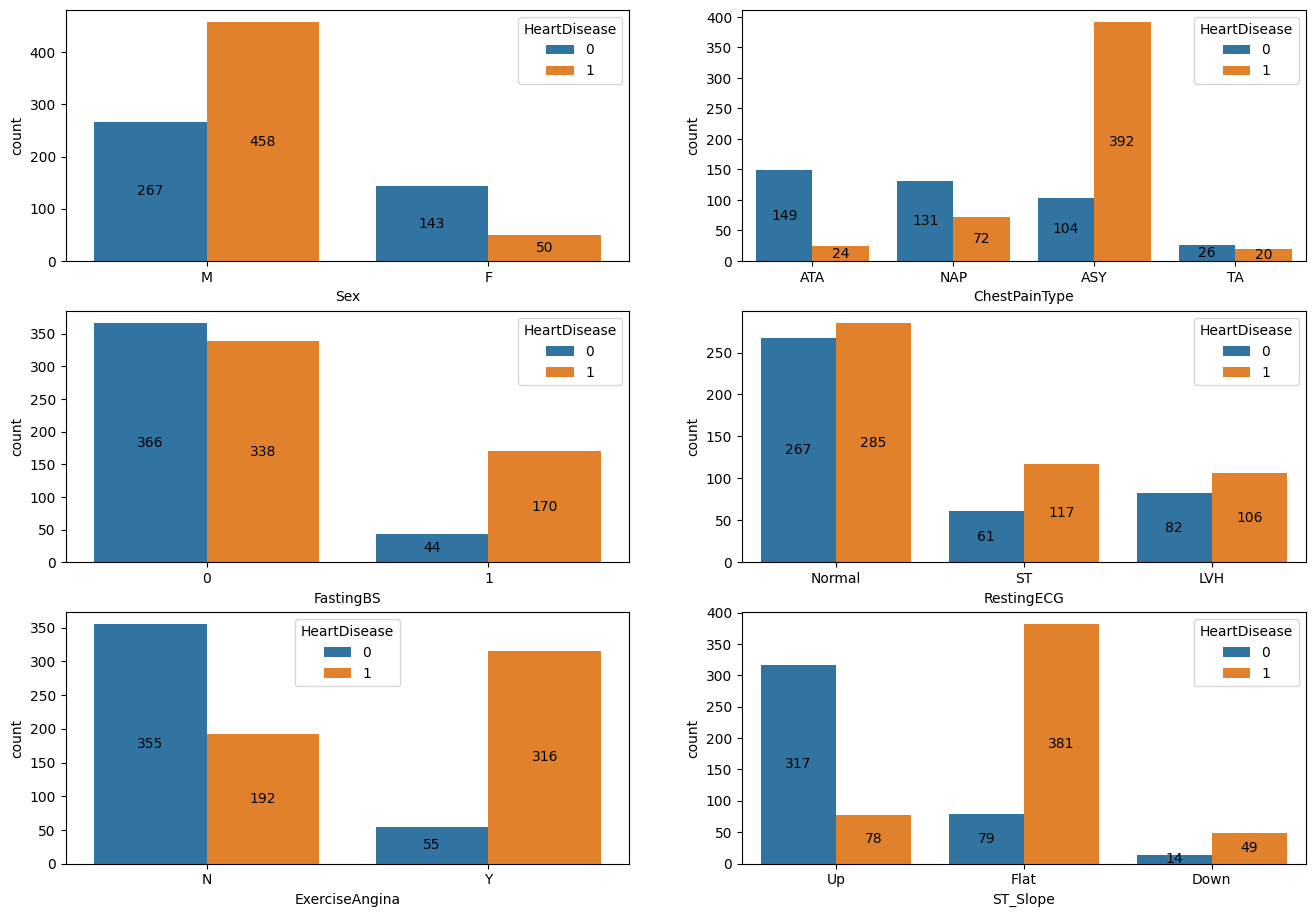

In [10]:
fig = plt.figure(figsize = (16, 15))

for idx, column in enumerate(categorical_column[:-1]):
    ax = plt.subplot(4, 2, idx+1)
    sns.countplot(x = heart_disease[column], hue=heart_disease["HeartDisease"] , ax = ax)
    for container in ax.containers:
        ax.bar_label(container, label_type="center")

- We can further notice how skewed the dataset is towards male patients. Only `50` female patients in the dataset have been diagnosed with heart disease.
- A significant number of patients, `392`, diagnosed with heart disease have asymptomatic (ASY) chest pain. While chest pain could be a relevant feature for our model, asymptomatic implies that those patients who had a heart disease did not have chest pain as a symptom. 
- A high number (`170`) of patients with blood sugar greater than 120 mg/dl were diagnosed with heart disease in relation to those who were not diagnosed as such.
- Out of all patients who had an exercise-induced angina, `316` were diagnosed with a heart disease.
- Out of all patients with a flat ST slope, `381` were diagnosed with a heart disease.

Looking at the data distribution from the above plots, we can start to identify some features that could be relevant to us. We will clean up the dataset a bit first before narrowing down on our features.

## Data Cleaning

In [11]:
# Count the number of rows that have a 0 value for RestingBP
zero_bp = (heart_disease['RestingBP'] == 0).sum()
zero_bp
heart_disease = heart_disease.drop(heart_disease[heart_disease['RestingBP'] == 0].index, axis = 0)


As there is only one row with zero bp we will remove that row.

In [12]:
zero_cholestrol = (heart_disease['Cholesterol'] == 0).sum()
zero_cholestrol

np.int64(171)

There are 171 missing value in  cholestrol columns. We will assign median value of cholesterol of people with heart diesease and people without heart disease.

In [13]:
median_no_heart_disease = heart_disease['Cholesterol'][heart_disease['HeartDisease'] == 0].median()
median_heart_disease = heart_disease['Cholesterol'][heart_disease['HeartDisease'] == 1].median()
# Replace zeros in Cholesterol for patients without heart disease
heart_disease.loc[
    (heart_disease['HeartDisease'] == 0) & (heart_disease['Cholesterol'] == 0),
    'Cholesterol'
] = median_no_heart_disease

# Replace zeros in Cholesterol for patients with heart disease
heart_disease.loc[
    (heart_disease['HeartDisease'] == 1) & (heart_disease['Cholesterol'] == 0),
    'Cholesterol'
] = median_heart_disease

In [14]:
zero_cholestrol = (heart_disease['Cholesterol'] == 0).sum()
zero_cholestrol

np.int64(0)

## Feature Selection

we can select features for our model. Thanks to our EDA and a general understanding of the features, we can identify some of the features that we could start with:

- Age
- Sex
- ChestPainType
- Cholesterol
- FastingBS

In [15]:
#  convert our categorical columns into dummy variables.

heart_disease = pd.get_dummies(heart_disease, drop_first = True)
heart_disease.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


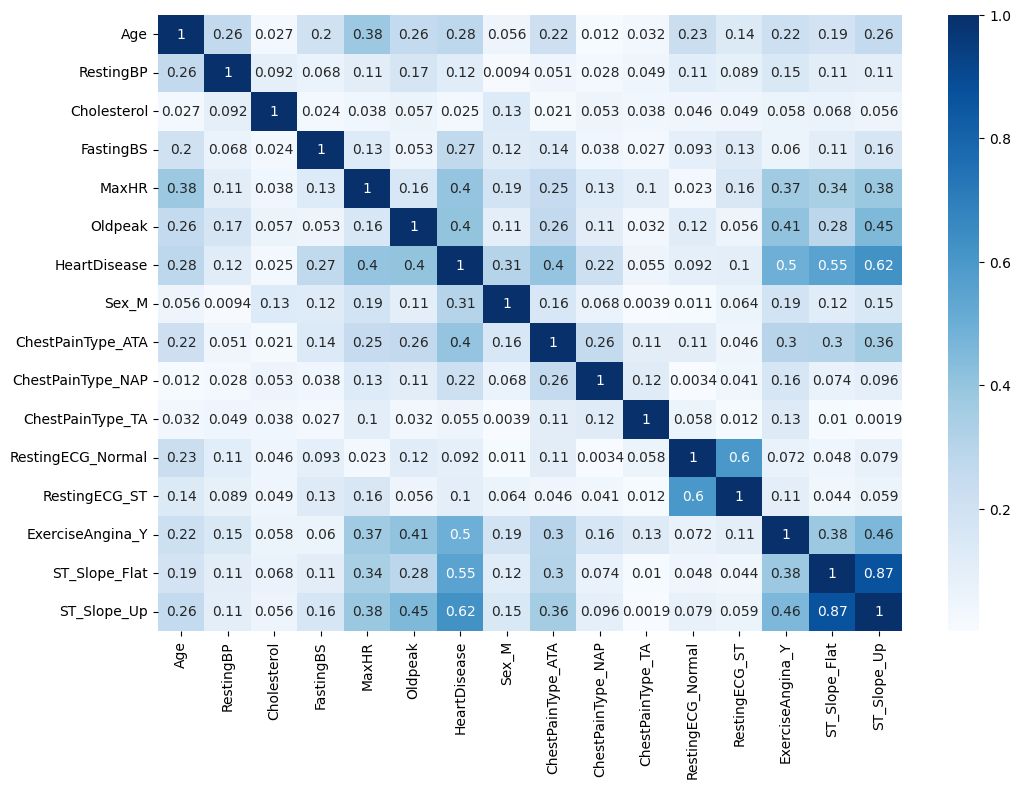

In [16]:
# Create a Pearson's correlation heat map.
correlations = abs(heart_disease.corr())
plt.figure(figsize = (12, 8))
sns.heatmap(data = correlations, annot = True, cmap = 'Blues')
plt.show()

<Axes: >

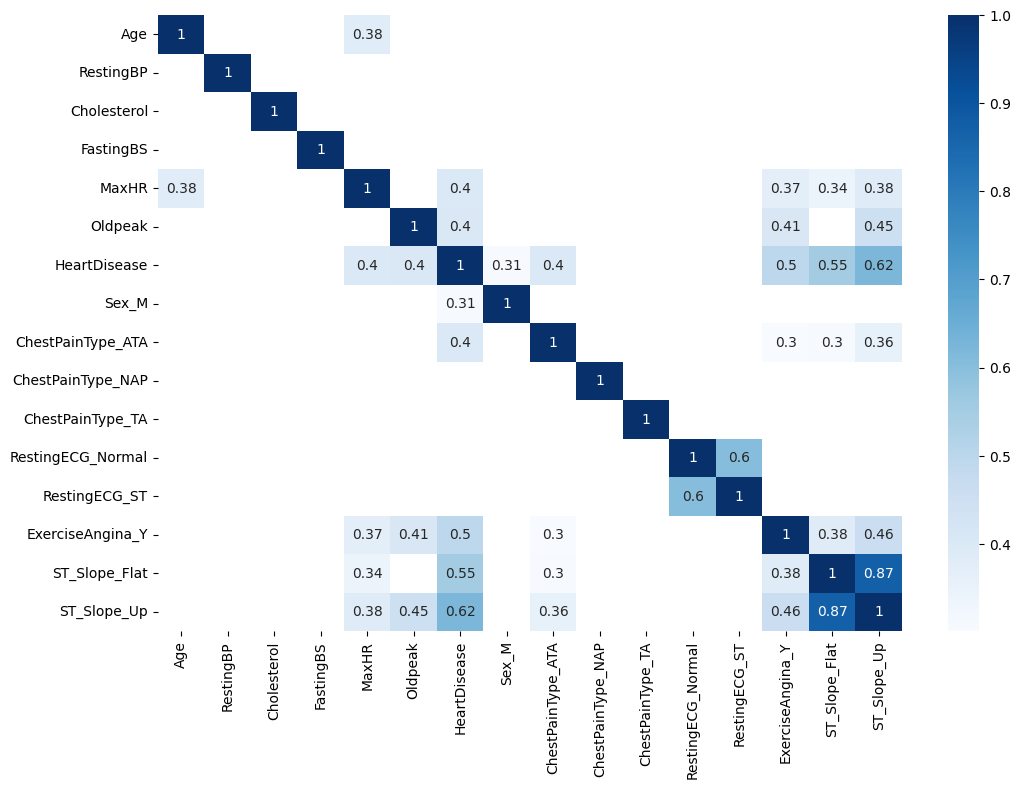

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(correlations[correlations > 0.3], annot=True, cmap="Blues")

From our correlation heatmap, we can identify the following features to be positively correlated (correlation coefficient greater than 0.3) to `HeartDisease`:

- `Oldpeak`
- `MaxHR`
- `ChestPainType_ATA` 
- `ExerciseAngina_Y`
- `ST_Slope_Flat`
- `ST_Slope_Up`

The correlation coefficient threshold was chosen arbitrarily. Surprisingly, `Cholesterol` is not strongly correlated to `HeartDisease`. We can consider ignoring the feature for now.

Given everything we have attempted so far, we can narrow down our features to the following:

- `Oldpeak`
- `Sex_M`
    - It has a relatively low value for the coefficient, but given what we observed in our EDA, let's also take it into account.
- `ExerciseAngina_Y`
- `ST_Slope_Flat`
- `ST_Slope_Up`

Time to create our model using these features!

## Building a Classifier I
we will create and train multiple models using one of those features at a time.

In [18]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

X = heart_disease.drop(['HeartDisease'], axis = 1)
y = heart_disease['HeartDisease']

# Split the dataset.
X_train, X_val, y_train, y_val = train_test_split(X, y , test_size = 0.2, random_state = 42)

feature_list = ['Oldpeak','Sex_M','ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']

In [19]:
# Create a k-NN classifier.

for feature in feature_list:
    model = KNeighborsClassifier(n_neighbors = 3)
    model.fit(X_train[[feature]], y_train)
    accuracy = model.score(X_val[[feature]], y_val)
    print(f'The accuracy of model with {feature} is {accuracy}.')
    print('-------------------------------- \n')
    
    
        

The accuracy of model with Oldpeak is 0.6141304347826086.
-------------------------------- 

The accuracy of model with Sex_M is 0.6086956521739131.
-------------------------------- 

The accuracy of model with ExerciseAngina_Y is 0.6739130434782609.
-------------------------------- 

The accuracy of model with ST_Slope_Flat is 0.7608695652173914.
-------------------------------- 

The accuracy of model with ST_Slope_Up is 0.391304347826087.
-------------------------------- 



The accuracy of model is hightest i.e. `76%` in  ST_Slope_Flat feature. In the meantime, ST_Slope_Up perform worse with `39%` accuracy in predicting heart disease.

## Building a Classifier II

In [20]:
# Normalize the features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[feature_list])
X_val_scaled  = scaler.transform(X_val[feature_list])

model = KNeighborsClassifier(n_neighbors = 3)
model.fit(X_train_scaled, y_train)
accuracy = model.score(X_val_scaled, y_val)
print(f'The accuracy of model with 3 neighbors is {accuracy}')

The accuracy of model with 3 neighbors is 0.7934782608695652


Model accuracy jumped to `79%` when all the feature are used for classifier.That's not a significant improvement, but still a good start. Using all these features results in an improved model, but, let's see what parameters/hyperparameters might be optimal.

## Hyperparameter Tuning

we can experiment with the parameters and hyperparameters. We'll use **GridSearchCV** to search over optimal parameter value.

Additionally, since GridSearchCV creates a validation set as part of its process, we'll have to update our workflow a bit.

In [23]:
# Split the dataset into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state = 42)

# Scale the training set.
X_train_scaled = scaler.fit_transform(X_train[feature_list])
X_test_scaled  = scaler.transform(X_test[feature_list])

grid_params = {'n_neighbors':[3,5,8,10], 'weights': ['uniform', 'distance'],'metric' : ['minkowski', 'manhattan']}

model = KNeighborsClassifier()
grid_search = GridSearchCV(model, grid_params, scoring = 'accuracy')
grid_search.fit(X_train_scaled, y_train)

best_score = grid_search.best_score_
best_params = grid_search.best_params_

print(best_score, best_params)

0.8457552884167365 {'metric': 'minkowski', 'n_neighbors': 10, 'weights': 'uniform'}


The model achieved `84.5%` accuracy when using these hyperparameter:'metric': 'minkowski', 'n_neighbors': 10, 'weights': 'uniform'}
We achieved an improvement of `5%` over the previous `79%` accuracy.

##  Model Evaluation on Test Set

We'll now evaluate this model on our test set.

In [24]:
accuracy = grid_search.best_estimator_.score(X_test_scaled, y_test)
print(accuracy)

0.7880434782608695


Test set accuracy is `78.8%` which indicate a lower accuracy compared to training set.